In [45]:
import pandas as pd
df=pd.read_csv("DecisionTree_Sports.csv")
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,Sunny,Hot,High,Weak,No
1,Day 2,Sunny,Hot,High,Strong,No
2,Day 3,Cloudy,Hot,High,Weak,Yes
3,Day 4,Rain,Mild,High,Weak,Yes
4,Day 5,Rain,Cool,Normal,Weak,Yes
5,Day 6,Rain,Cool,Normal,Strong,No
6,Day 7,Cloudy,Cool,Normal,Strong,Yes
7,Day 8,Sunny,Mild,High,Weak,No
8,Day 9,Sunny,Cool,Normal,Weak,Yes
9,Day 10,Rain,Mild,Normal,Weak,Yes


In [46]:
import numpy as np
df["Weather"]=np.where(df["Weather"]=="Sunny",2,np.where(df["Weather"]=="Cloudy",0,1))
df["Temperature"]=np.where(df["Temperature"]=="Hot",1,np.where(df["Temperature"]=="Mild",2,0))
df["Humidity"]=np.where(df["Humidity"]=="High",0,1)
df["Wind"]=np.where(df["Wind"]=="Weak",1,0)
df["Play_Sports?"]=np.where(df["Play_Sports?"]=="No",0,1)
df

,Day,Weather,Temperature,Humidity,Wind,Play_Sports?
0,Day 1,2,1,0,1,0
1,Day 2,2,1,0,0,0
2,Day 3,0,1,0,1,1
3,Day 4,1,2,0,1,1
4,Day 5,1,0,1,1,1
5,Day 6,1,0,1,0,0
6,Day 7,0,0,1,0,1
7,Day 8,2,2,0,1,0
8,Day 9,2,0,1,1,1
9,Day 10,1,2,1,1,1


In [47]:
x=df[["Weather","Temperature","Humidity","Wind"]]
y=df["Play_Sports?"]
print(x.shape)
print(y.shape)

(14, 4)
(14,)


In [48]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion="entropy")#default value criterion="gini"
model=dtree.fit(x,y)
prediction=model.predict(x)
print(prediction)

[0 0 1 1 1 0 1 0 1 1 1 1 1 0]


In [49]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)

[[5 0]
 [0 9]]


In [50]:
from sklearn.metrics import accuracy_score
print("Accuracy:",accuracy_score(y,prediction))

Accuracy: 1.0


In [51]:
dtree.get_depth()

4

In [52]:
from sklearn import tree
text_representation=tree.export_text(dtree,feature_names=["Weather","Temperature","Humidity","Wind"])
print(text_representation)

|--- Weather <= 0.50
|   |--- class: 1
|--- Weather >  0.50
|   |--- Humidity <= 0.50
|   |   |--- Weather <= 1.50
|   |   |   |--- Wind <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Wind >  0.50
|   |   |   |   |--- class: 1
|   |   |--- Weather >  1.50
|   |   |   |--- class: 0
|   |--- Humidity >  0.50
|   |   |--- Wind <= 0.50
|   |   |   |--- Temperature <= 1.00
|   |   |   |   |--- class: 0
|   |   |   |--- Temperature >  1.00
|   |   |   |   |--- class: 1
|   |   |--- Wind >  0.50
|   |   |   |--- class: 1



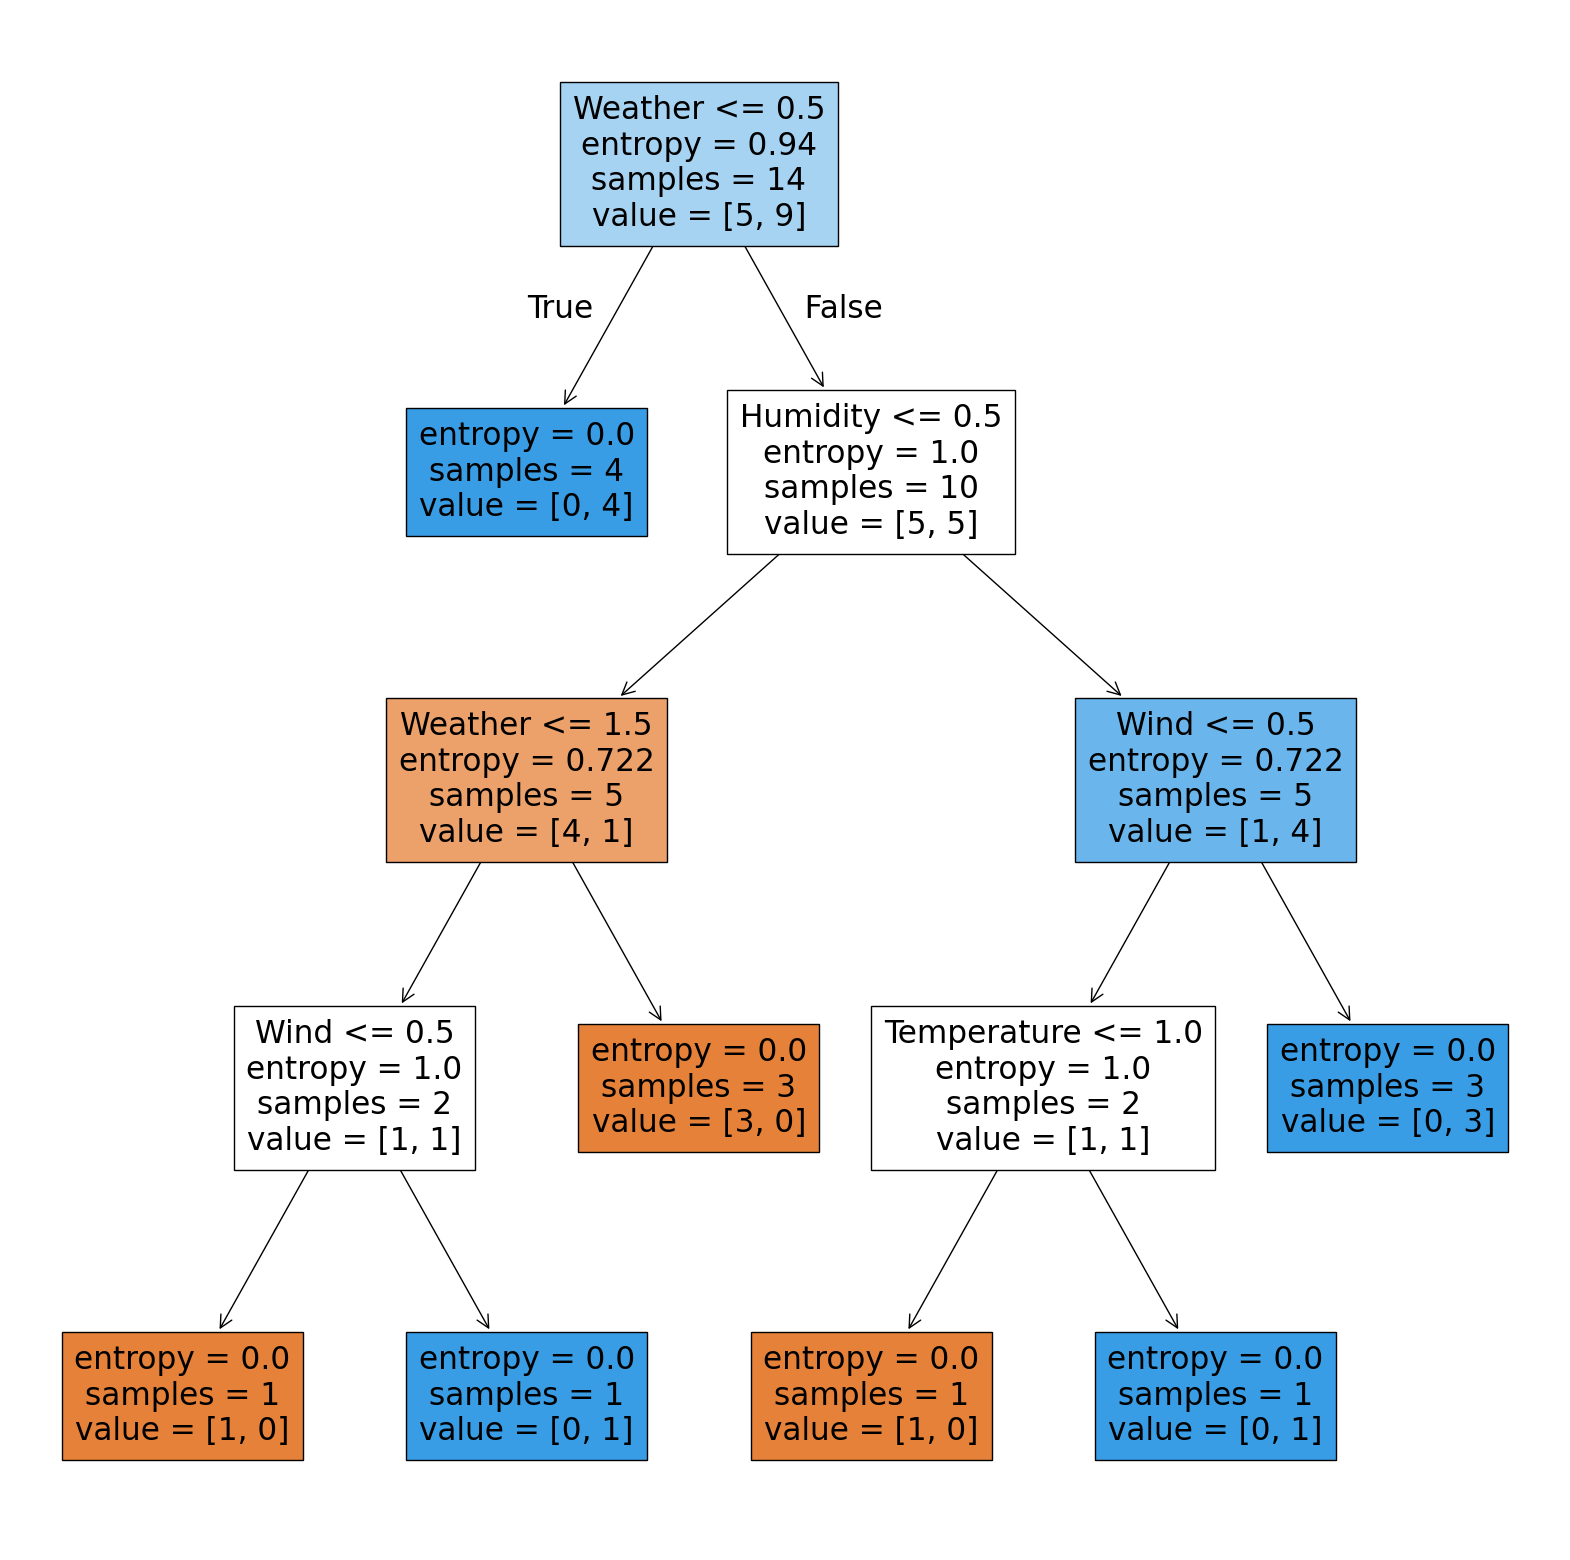

In [53]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,20))
plot_tree(dtree,feature_names=list(x.columns),filled=True)
plt.show()

In [17]:
df.to_excel("DecisionTree_Sports.xlsx")

In [61]:
result=pd.get_dummies(data=df,columns=["Weather","Temperature","Humidity","Wind"])
result

,Day,Play_Sports?,Weather_0,Weather_1,Weather_2,Temperature_0,Temperature_1,Temperature_2,Humidity_0,Humidity_1,Wind_0,Wind_1
0,Day 1,0,False,False,True,False,True,False,True,False,False,True
1,Day 2,0,False,False,True,False,True,False,True,False,True,False
2,Day 3,1,True,False,False,False,True,False,True,False,False,True
3,Day 4,1,False,True,False,False,False,True,True,False,False,True
4,Day 5,1,False,True,False,True,False,False,False,True,False,True
5,Day 6,0,False,True,False,True,False,False,False,True,True,False
6,Day 7,1,True,False,False,True,False,False,False,True,True,False
7,Day 8,0,False,False,True,False,False,True,True,False,False,True
8,Day 9,1,False,False,True,True,False,False,False,True,False,True
9,Day 10,1,False,True,False,False,False,True,False,True,False,True


In [62]:
x=result.iloc[:,2:]
y=result["Play_Sports?"]
print(x.shape)
print(y.shape)

(14, 10)
(14,)


In [63]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion="entropy")
model=dtree.fit(x,y)
prediction=model.predict(x)
print(prediction)

[0 0 1 1 1 0 1 0 1 1 1 1 1 0]


In [64]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y,prediction)
print(cm)

[[5 0]
 [0 9]]


In [65]:
from sklearn.metrics import accuracy_score
print("Accuracy:",accuracy_score(y,prediction))

Accuracy: 1.0


In [66]:
from sklearn import tree
text_representation=tree.export_text(dtree,feature_names=list(x.columns))
print(text_representation)

|--- Weather_0 <= 0.50
|   |--- Humidity_1 <= 0.50
|   |   |--- Weather_2 <= 0.50
|   |   |   |--- Wind_1 <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Wind_1 >  0.50
|   |   |   |   |--- class: 1
|   |   |--- Weather_2 >  0.50
|   |   |   |--- class: 0
|   |--- Humidity_1 >  0.50
|   |   |--- Wind_0 <= 0.50
|   |   |   |--- class: 1
|   |   |--- Wind_0 >  0.50
|   |   |   |--- Temperature_2 <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- Temperature_2 >  0.50
|   |   |   |   |--- class: 1
|--- Weather_0 >  0.50
|   |--- class: 1



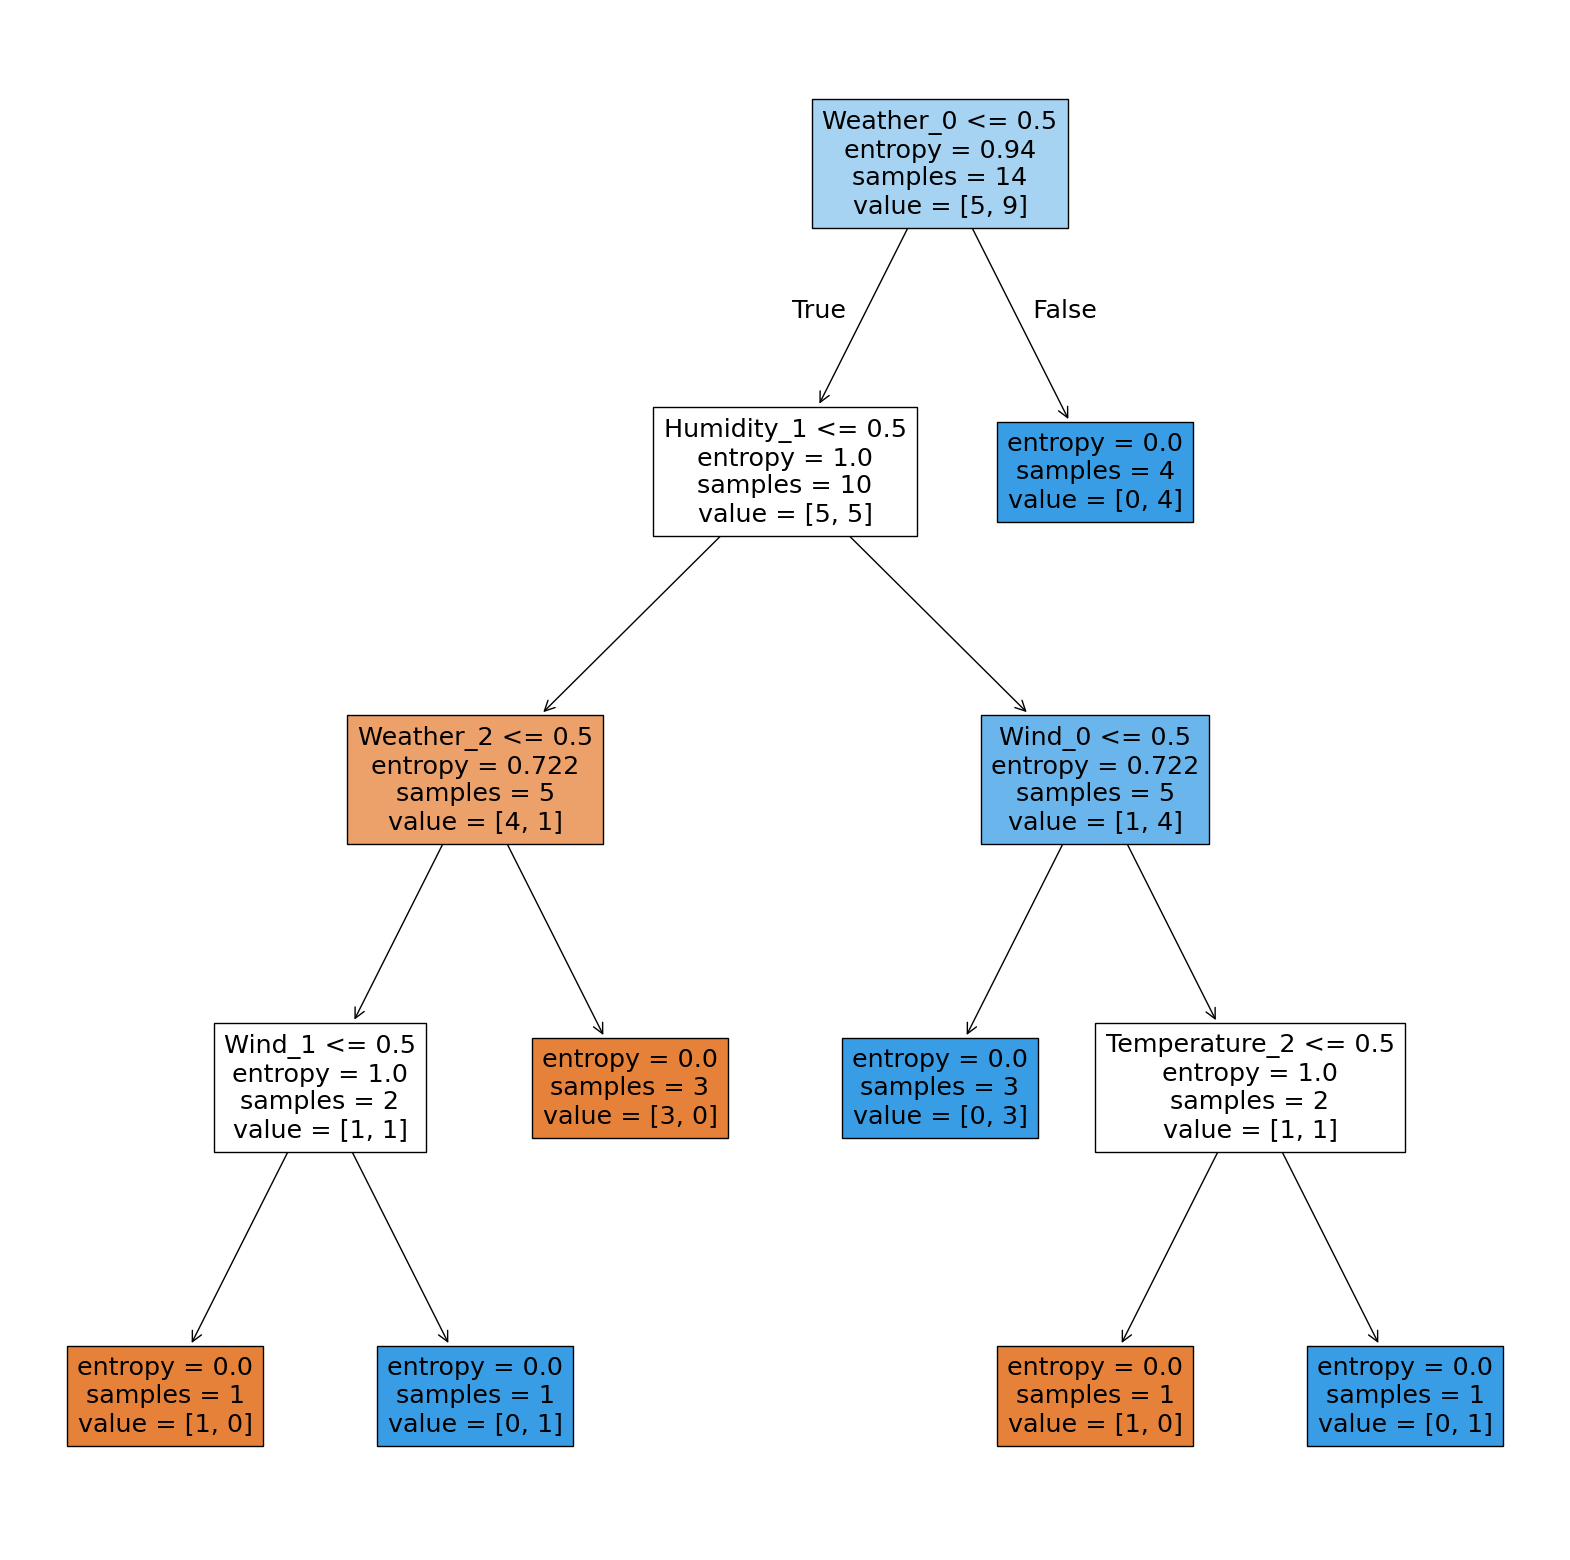

In [67]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,20))
plot_tree(dtree,feature_names=list(x.columns),filled=True)
plt.show()

In [69]:
result.to_excel("DecisionTree_Sports.xlsx")

In [70]:
df=pd.read_csv("DecisionTreeDataset -Num.csv")
df

,CGPA,Communication,Apptitude,Programming Skill,Job Offered
0,2,1,1,1,1
1,1,1,1,1,1
2,0,0,0,1,0
3,0,1,0,0,0
4,2,1,1,0,1
5,2,1,1,1,1
6,1,0,0,0,0
7,1,0,0,1,0
8,2,0,1,1,1
9,1,1,1,1,1


In [71]:
x=df.iloc[:,0:3]
y=df["Job Offered"]
print(x.shape)
print(y.shape)

(18, 3)
(18,)


In [73]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion="entropy")
model=dtree.fit(x,y)
prediction=model.predict(x)
print(prediction)

[1 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 0 1]


In [74]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
cm=confusion_matrix(y,prediction)
print(cm)
print("Accuracy:",accuracy_score(y,prediction))

[[10  0]
 [ 0  8]]
Accuracy: 1.0


In [75]:
from sklearn import tree
text_representation=tree.export_text(dtree,feature_names=list(x.columns))
print(text_representation)

|--- Apptitude <= 0.50
|   |--- class: 0
|--- Apptitude >  0.50
|   |--- Communication <= 0.50
|   |   |--- CGPA <= 1.50
|   |   |   |--- class: 0
|   |   |--- CGPA >  1.50
|   |   |   |--- class: 1
|   |--- Communication >  0.50
|   |   |--- class: 1



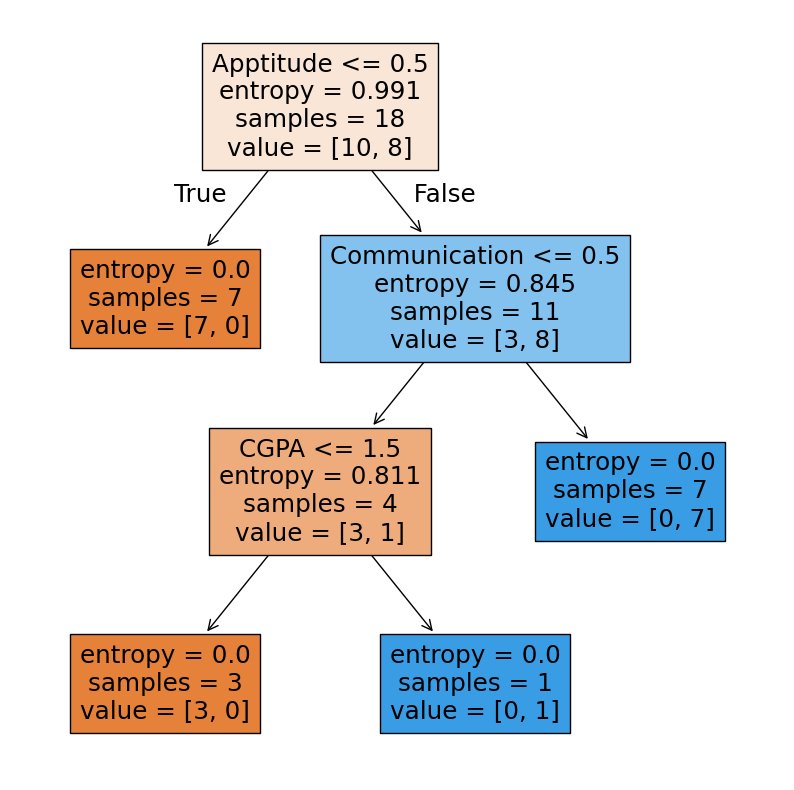

In [77]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(10,10))
plot_tree(dtree,feature_names=list(x.columns),filled=True)
plt.show()

In [99]:
df=pd.read_csv("titanic.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [100]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [101]:
x=df[["Parch","Sex","Age","SibSp","Pclass","Fare"]]
y=df["Survived"]

In [102]:
import warnings
warnings.filterwarnings("ignore")
x['Sex']=x["Sex"].map({"female":0,"male":1})
x["Age"]=x["Age"].fillna(x["Age"].mean())

In [103]:
x

,Parch,Sex,Age,SibSp,Pclass,Fare
0,0,1,22.000000,1,3,7.2500
1,0,0,38.000000,1,1,71.2833
2,0,0,26.000000,0,3,7.9250
3,0,0,35.000000,1,1,53.1000
4,0,1,35.000000,0,3,8.0500
...,...,...,...,...,...,...
886,0,1,27.000000,0,2,13.0000
887,0,0,19.000000,0,1,30.0000
888,2,0,29.699118,1,3,23.4500
889,0,1,26.000000,0,1,30.0000


In [115]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(712, 6)
(712,)
(179, 6)
(179,)


In [117]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=7)
model=nn.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[1 0 1 1 1 0 0 1 1 1 0 0 1 1 1 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 0 1 0 0 0 0 1
 0 1 0 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0
 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0
 0 0 0 0 0 0 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 0 0 0 0
 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0 1 1 0 1 0 1 0 0 0 1]


In [118]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,prediction)
print(cm)

[[92 14]
 [33 40]]


In [119]:
from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(y_test,prediction))

Accuracy Score: 0.7374301675977654


In [120]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(criterion="entropy")#default value criterion="gini"
model=dtree.fit(x,y)
prediction=model.predict(x)
print(prediction)

[0 1 1 1 0 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 0 1 0 0 1 0 0 1 1 0 0 0 0
 0 0 1 0 0 0 1 1 0 0 1 0 0 0 0 1 1 0 1 1 0 1 0 0 1 0 0 0 1 1 0 1 0 0 0 0 0
 1 0 0 0 1 1 0 1 1 0 1 1 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 1 0
 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1
 0 1 0 0 0 1 0 1 1 1 1 0 0 1 0 0 0 0 0 1 0 0 1 1 1 0 1 0 0 0 1 1 0 1 0 0 0
 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 0 0 1 1 1 1
 1 0 1 0 0 1 0 0 0 1 1 0 1 1 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0
 0 0 1 1 1 1 0 1 0 1 1 1 0 1 1 1 0 0 0 1 1 0 1 1 0 0 1 1 0 1 0 1 1 1 1 0 0
 0 1 0 0 1 1 0 1 1 0 0 0 0 1 1 1 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 1 1 1 1
 1 0 0 0 0 1 1 0 0 0 1 1 0 1 0 0 0 1 0 1 1 1 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0
 1 0 0 0 0 1 0 1 0 1 1 0 0 0 0 0 0 0 0 1 1 0 1 1 1 1 0 0 1 0 1 0 0 1 0 0 1
 1 1 1 1 1 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 0
 0 0 1 1 0 1 0 0 1 0 0 0 

In [121]:
from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(y_test,prediction))

ValueError: Found input variables with inconsistent numbers of samples: [179, 891]